# 🏦 Bank Loan Default Analytics
### Predicting loan default risk using machine learning and SQL-powered analytics

---

> **Author:** Shubham Jaiswal  
> **Dataset:** Home Credit Default Risk (Kaggle)  
> **Tools:** Python · SQL · Scikit-learn · XGBoost · Streamlit · Plotly

## 📊 Exploratory Data Analysis (EDA)
#### Bank Loan Default Analytics

---

> **Notebook 1 of 5**  
> **Goal:** Understand the dataset structure, distributions, missing values, and relationships between features before modeling.  
> **Input:** `application_train.csv` (raw)  
> **Output:** Insights, charts saved to `images/`

### Step 1 — Importing Libraries
Importing all required libraries for data manipulation, visualization, and machine learning.

In [2]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
import sklearn
import xgboost

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("sklearn    :", sklearn.__version__)
print("xgboost    :", xgboost.__version__)
print("\n✅ All libraries imported successfully")

pandas     : 3.0.3
numpy      : 2.4.6
sklearn    : 1.8.0
xgboost    : 3.2.0

✅ All libraries imported successfully


### Step 2 — Loading the Dataset
Loading `application_train.csv` — the main dataset with 307,511 loan applications and 122 features.  
This is the primary table containing applicant information and the `TARGET` column (1 = defaulted, 0 = repaid).

In [3]:
# Load main dataset
df = pd.read_csv('../data/raw/application_train.csv')

print(f"✅ Dataset loaded successfully")
print(f"📊 Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🎯 Target column: {df['TARGET'].value_counts().to_dict()}")
print(f"💾 Memory usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ Dataset loaded successfully
📊 Shape        : 307,511 rows × 122 columns
🎯 Target column: {0: 282686, 1: 24825}
💾 Memory usage : 325.22 MB


### Step 3 — First Look at the Data
Quick inspection of the dataset — first few rows, data types, and basic structure.

In [4]:
# First 5 rows
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,0.069,0.083,0.125,0.037,0.020,0.019,0.000,0.000,0.025,0.038,0.972,0.634,0.014,0.000,0.069,0.083,0.125,0.038,0.022,0.020,0.000,0.000,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,0.035,0.292,0.333,0.013,0.077,0.055,0.004,0.010,0.092,0.054,0.985,0.804,0.050,0.081,0.035,0.292,0.333,0.013,0.079,0.055,0.000,0.000,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
# Shape and data types
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")

Rows    : 307,511
Columns : 122

Data Types:
float64    65
int64      41
str        16
Name: count, dtype: int64


In [6]:
# Basic statistics
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000,307511.000,307511.000,307511.000,307511.000,307499.000,307233.000,307511.000,307511.000,307511.000,307511.000,307511.000,104582.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307509.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,134133.000,306851.000,246546.000,151450.000,127568.000,157504.000,103023.000,92646.000,143620.000,152683.000,154491.000,98869.000,124921.000,97312.000,153161.000,93997.000,137829.000,151450.000,127568.000,157504.000,103023.000,92646.000,143620.000,152683.000,154491.000,98869.000,124921.000,97312.000,153161.000,93997.000,137829.000,151450.000,127568.000,157504.000,103023.000,92646.000,143620.000,152683.000,154491.000,98869.000,124921.000,97312.000,153161.000,93997.000,137829.000,159080.000,306490.000,306490.000,306490.000,306490.000,307510.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,307511.000,265992.000,265992.000,265992.000,265992.000,265992.000,265992.000
mean,278180.519,0.081,0.417,168797.919,599026.000,27108.574,538396.207,0.021,-16036.995,63815.046,-4986.120,-2994.202,12.061,1.000,0.820,0.199,0.998,0.281,0.057,2.153,2.052,2.032,12.063,0.015,0.051,0.041,0.078,0.230,0.180,0.502,0.514,0.511,0.117,0.088,0.978,0.752,0.045,0.079,0.150,0.226,0.232,0.066,0.101,0.107,0.009,0.028,0.114,0.088,0.977,0.760,0.043,0.074,0.145,0.222,0.228,0.065,0.106,0.106,0.008,0.027,0.118,0.088,0.978,0.756,0.045,0.078,0.149,0.226,0.232,0.067,0.102,0.109,0.009,0.028,0.103,1.422,0.143,1.405,0.100,-962.859,0.000,0.710,0.000,0.015,0.088,0.000,0.081,0.004,0.000,0.004,0.000,0.004,0.003,0.001,0.010,0.000,0.008,0.001,0.001,0.000,0.006,0.007,0.034,0.267,0.265,1.900
std,102790.175,0.272,0.722,237123.146,402490.777,14493.737,369446.461,0.014,4363.989,141275.767,3522.886,1509.450,11.945,0.002,0.384,0.400,0.043,0.450,0.231,0.911,0.509,0.503,3.266,0.122,0.220,0.197,0.268,0.421,0.384,0.211,0.191,0.195,

### Step 4 — Missing Value Analysis
Identifying columns with missing values, their count and percentage.  
This helps us decide which columns to drop, impute, or flag.

In [7]:
# Missing value count and percentage
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing)} out of {df.shape[1]}")
missing.head(20)

Columns with missing values: 67 out of 122


,Missing Count,Missing %
COMMONAREA_MEDI,214865,69.872
COMMONAREA_MODE,214865,69.872
COMMONAREA_AVG,214865,69.872
NONLIVINGAPARTMENTS_MODE,213514,69.433
NONLIVINGAPARTMENTS_MEDI,213514,69.433
NONLIVINGAPARTMENTS_AVG,213514,69.433
FONDKAPREMONT_MODE,210295,68.386
LIVINGAPARTMENTS_AVG,210199,68.355
LIVINGAPARTMENTS_MEDI,210199,68.355
LIVINGAPARTMENTS_MODE,210199,68.355


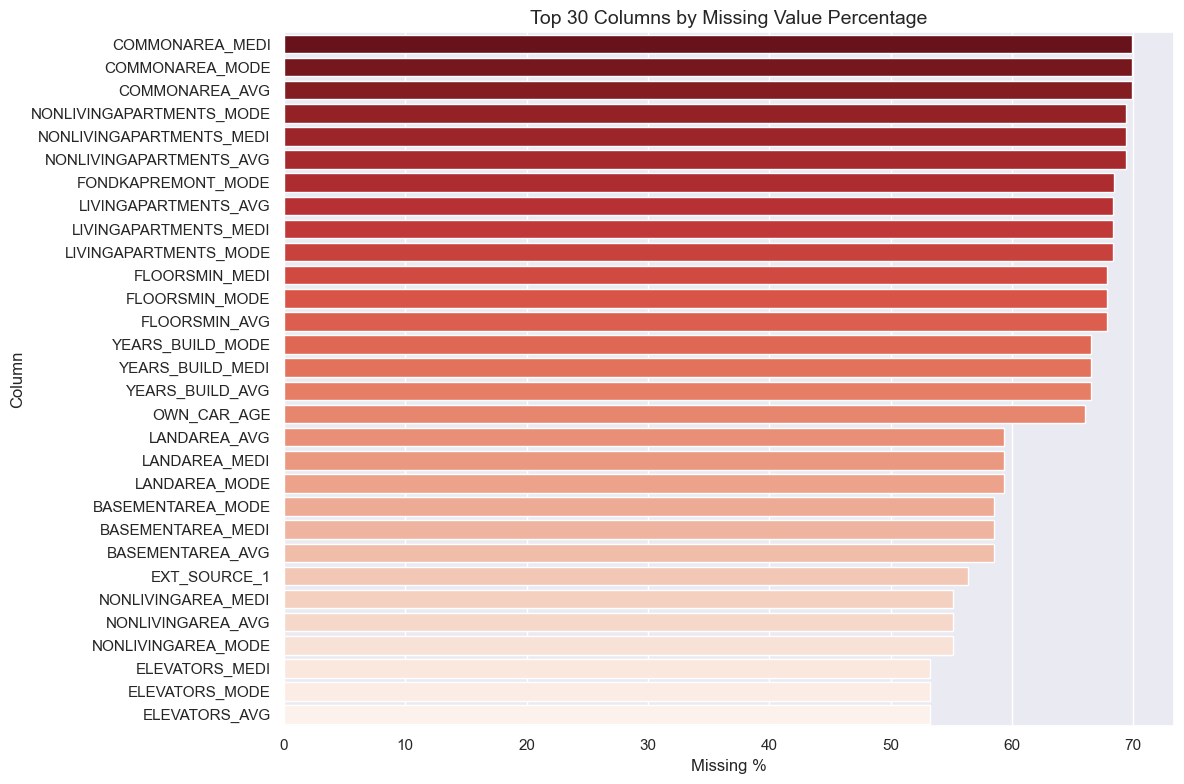

✅ Chart saved to images/missing_values.png


In [8]:
# Visualize top 30 columns with most missing values
top_missing = missing.head(30)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_missing['Missing %'], y=top_missing.index, palette='Reds_r')
plt.title('Top 30 Columns by Missing Value Percentage', fontsize=14)
plt.xlabel('Missing %')
plt.ylabel('Column')
plt.tight_layout()
plt.savefig('../images/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/missing_values.png")

> **Decision Rule:**
> - Missing > 40% → candidate for dropping
> - Missing 10–40% → impute with median/mode
> - Missing < 10% → impute safely

### Step 5 — Target Distribution
Analyzing the distribution of the target variable.  
`TARGET = 1` means the client defaulted, `TARGET = 0` means the loan was repaid successfully.

In [9]:
# Target distribution count
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("Target Distribution:")
print(f"  Repaid    (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"  Defaulted (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\n⚠️ Class imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1")

Target Distribution:
  Repaid    (0): 282,686 (91.93%)
  Defaulted (1): 24,825 (8.07%)

⚠️ Class imbalance ratio: 11.4:1


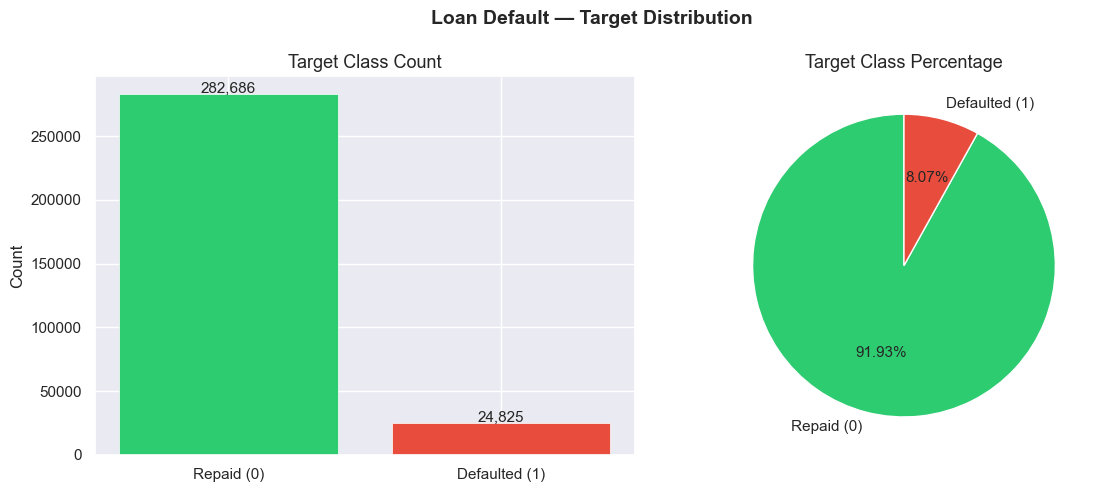

✅ Chart saved to images/target_distribution.png


In [10]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Repaid (0)', 'Defaulted (1)'], target_counts, color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Target Class Count', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_counts, labels=['Repaid (0)', 'Defaulted (1)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Target Class Percentage', fontsize=13)

plt.suptitle('Loan Default — Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/target_distribution.png")

> **Key Insight:**  
> The dataset is heavily imbalanced — only ~8% of loans defaulted.  
> We will handle this using **SMOTE** during model training to avoid biased predictions.

### Step 6 — Numerical Feature Distribution
Analyzing the distribution of key numerical features.  
Understanding the spread, skewness, and outliers in important columns.

In [11]:
# Select key numerical columns for analysis
num_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'CNT_CHILDREN',
    'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

# Basic stats for these columns
df[num_cols].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,CNT_CHILDREN,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,307511.000,307511.000,307499.000,307233.000,307511.000,307511.000,307511.000,307511.000,307511.000,307509.000,134133.000,306851.000,246546.000
mean,168797.919,599026.000,27108.574,538396.207,-16036.995,63815.046,-4986.120,-2994.202,0.417,2.153,0.502,0.514,0.511
std,237123.146,402490.777,14493.737,369446.461,4363.989,141275.767,3522.886,1509.450,0.722,0.911,0.211,0.191,0.195
min,25650.000,45000.000,1615.500,40500.000,-25229.000,-17912.000,-24672.000,-7197.000,0.000,1.000,0.015,0.000,0.001
25%,112500.000,270000.000,16524.000,238500.000,-19682.000,-2760.000,-7479.500,-4299.000,0.000,2.000,0.334,0.392,0.371
50%,147150.000,513531.000,24903.000,450000.000,-15750.000,-1213.000,-4504.000,-3254.000,0.000,2.000,0.506,0.566,0.535
75%,202500.000,808650.000,34596.000,679500.000,-12413.000,-289.000,-2010.000,-1720.000,1.000,3.000,0.675,0.664,0.669
max,117000000.000,4050000.000,258025.500,4050000.000,-7489.000,365243.000,0.000,0.000,19.000,20.000,0.963,0.855,0.896


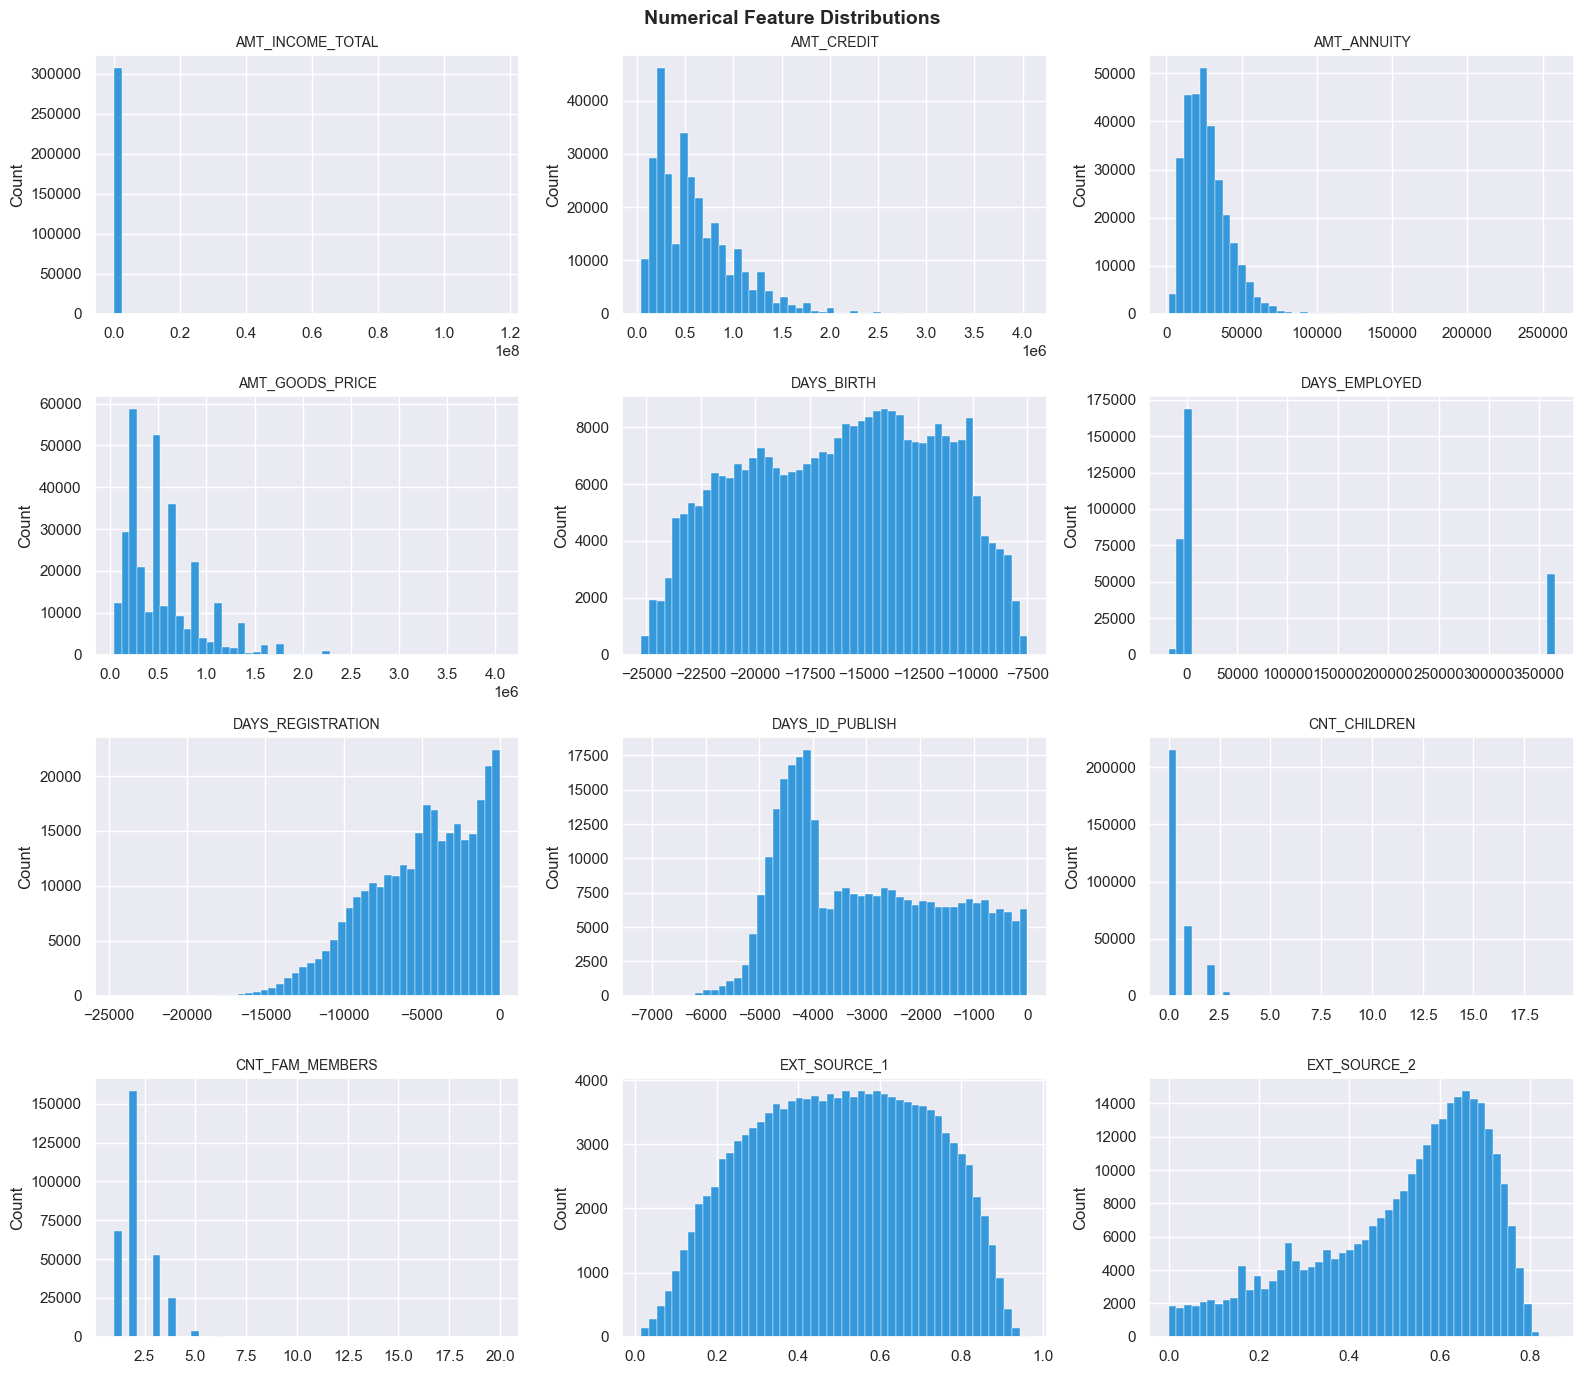

✅ Chart saved to images/numerical_distributions.png


In [12]:
# Distribution plots for key numerical features
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols[:12]):
    axes[i].hist(df[col].dropna(), bins=50, color='#3498db', edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/numerical_distributions.png")

> **Note on DAYS columns:**  
> `DAYS_BIRTH`, `DAYS_EMPLOYED` etc. are stored as negative integers — they represent days before the application date.  
> We will convert these to positive values (age in years, employment years) during feature engineering.

In [13]:
# Convert DAYS_BIRTH to Age in Years for better readability
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)

# DAYS_EMPLOYED has an anomaly — 365243 means unemployed
df['DAYS_EMPLOYED_CLEAN'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED_CLEAN'] / 365)

print(f"Age range       : {df['AGE_YEARS'].min()} – {df['AGE_YEARS'].max()} years")
print(f"Employment range: {df['YEARS_EMPLOYED'].min():.1f} – {df['YEARS_EMPLOYED'].max():.1f} years")
print(f"Anomalous DAYS_EMPLOYED (365243) count: {(df['DAYS_EMPLOYED'] == 365243).sum():,}")

Age range       : 20 – 69 years
Employment range: -0.0 – 49.1 years
Anomalous DAYS_EMPLOYED (365243) count: 55,374


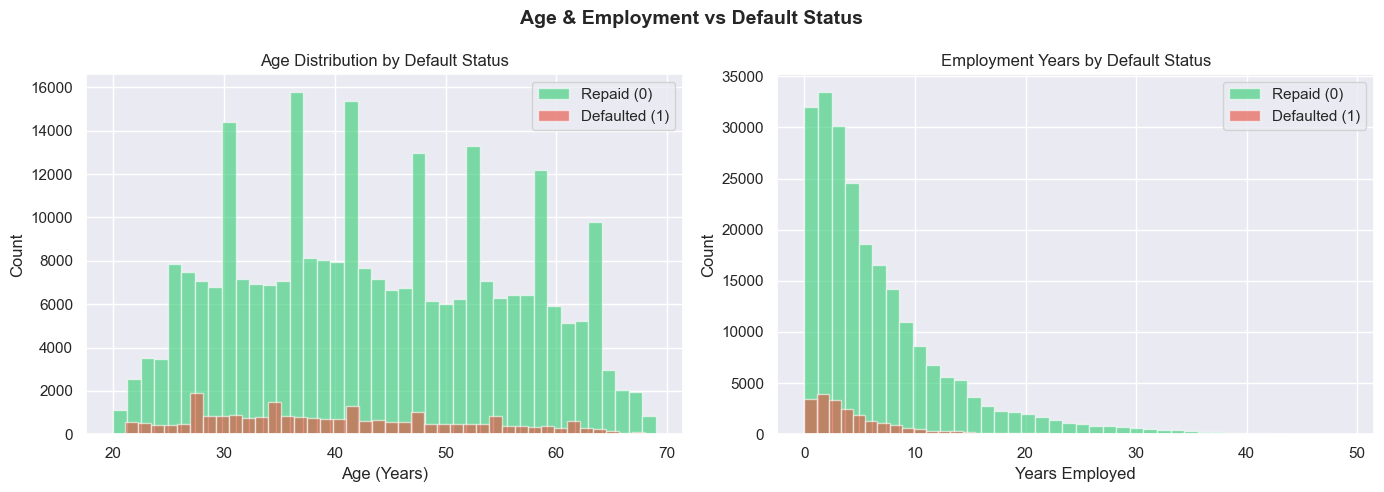

✅ Chart saved to images/age_employment_vs_default.png


In [14]:
# Age vs Default Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by target
axes[0].hist(df[df['TARGET']==0]['AGE_YEARS'], bins=40, alpha=0.6, color='#2ecc71', label='Repaid (0)')
axes[0].hist(df[df['TARGET']==1]['AGE_YEARS'], bins=40, alpha=0.6, color='#e74c3c', label='Defaulted (1)')
axes[0].set_title('Age Distribution by Default Status', fontsize=12)
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Employment years distribution by target
axes[1].hist(df[df['TARGET']==0]['YEARS_EMPLOYED'].dropna(), bins=40, alpha=0.6, color='#2ecc71', label='Repaid (0)')
axes[1].hist(df[df['TARGET']==1]['YEARS_EMPLOYED'].dropna(), bins=40, alpha=0.6, color='#e74c3c', label='Defaulted (1)')
axes[1].set_title('Employment Years by Default Status', fontsize=12)
axes[1].set_xlabel('Years Employed')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Age & Employment vs Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/age_employment_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/age_employment_vs_default.png")

### Step 7 — Categorical Feature Analysis
Analyzing key categorical columns and their relationship with the target variable (default rate).

In [15]:
# Select key categorical columns
cat_cols = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

# Default rate per category
for col in cat_cols:
    print(f"\n{col}:")
    print(df.groupby(col)['TARGET'].mean().sort_values(ascending=False).round(3))


NAME_CONTRACT_TYPE:
NAME_CONTRACT_TYPE
Cash loans        0.083
Revolving loans   0.055
Name: TARGET, dtype: float64

CODE_GENDER:
CODE_GENDER
M     0.101
F     0.070
XNA   0.000
Name: TARGET, dtype: float64

FLAG_OWN_CAR:
FLAG_OWN_CAR
N   0.085
Y   0.072
Name: TARGET, dtype: float64

FLAG_OWN_REALTY:
FLAG_OWN_REALTY
N   0.083
Y   0.080
Name: TARGET, dtype: float64

NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Maternity leave        0.400
Unemployed             0.364
Working                0.096
Commercial associate   0.075
State servant          0.058
Pensioner              0.054
Businessman            0.000
Student                0.000
Name: TARGET, dtype: float64

NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Lower secondary                 0.109
Secondary / secondary special   0.089
Incomplete higher               0.085
Higher education                0.054
Academic degree                 0.018
Name: TARGET, dtype: float64

NAME_FAMILY_STATUS:
NAME_FAMILY_STATUS
Civil marriage         0.099
Singl

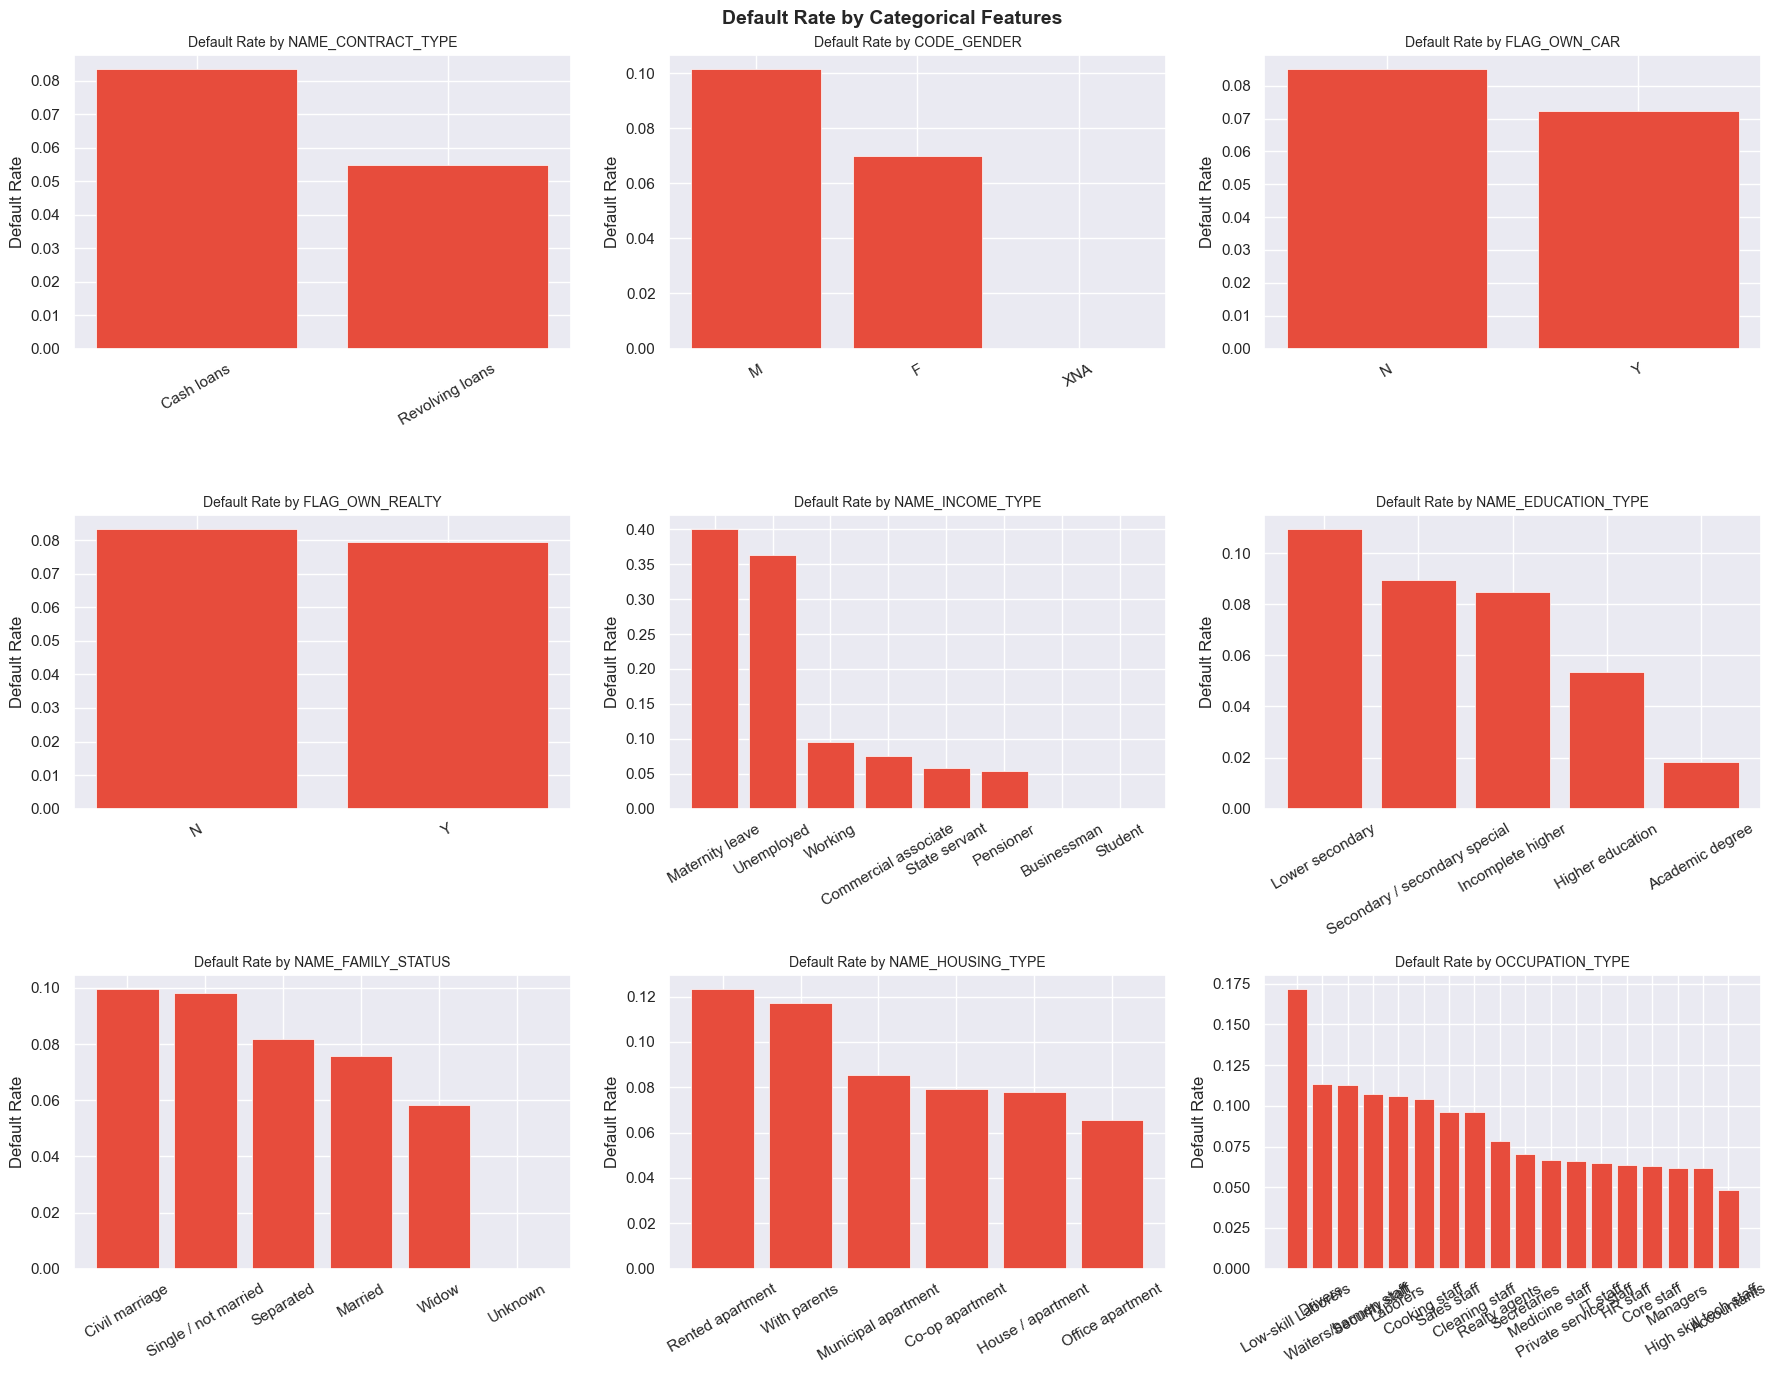

✅ Chart saved to images/categorical_default_rates.png


In [16]:
# Visualize default rate for top categorical features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    axes[i].bar(default_rate.index, default_rate.values, color='#e74c3c', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Default Rate by {col}', fontsize=10)
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/categorical_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/categorical_default_rates.png")

> **Key Insights:**
> - **Gender** — Male clients have a slightly higher default rate than female
> - **Contract Type** — Cash loans default more than revolving loans
> - **Education** — Lower education levels correlate with higher default risk
> - **Income Type** — Unemployed and maternity leave applicants show highest default rates

### Step 8 — Loan Amount vs Default Analysis
Analyzing how loan amount, credit amount, and annuity relate to default risk.

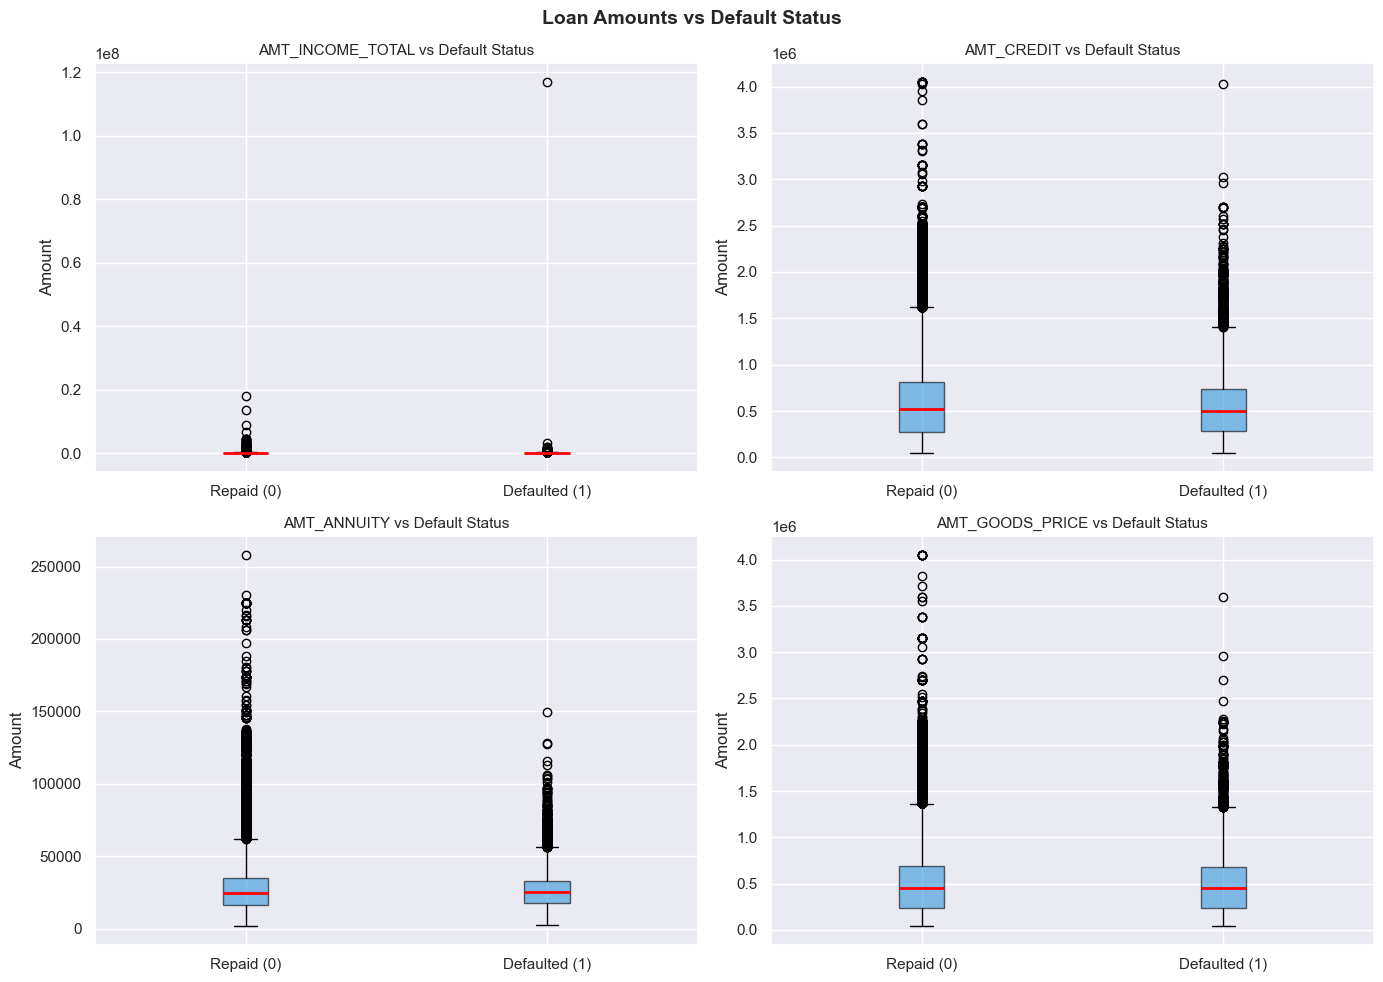

✅ Chart saved to images/loan_amounts_vs_default.png


In [17]:
# Loan amount columns vs default
loan_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(loan_cols):
    axes[i].boxplot(
        [df[df['TARGET']==0][col].dropna(), df[df['TARGET']==1][col].dropna()],
        labels=['Repaid (0)', 'Defaulted (1)'],
        patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.6),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(f'{col} vs Default Status', fontsize=11)
    axes[i].set_ylabel('Amount')

plt.suptitle('Loan Amounts vs Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/loan_amounts_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/loan_amounts_vs_default.png")

### Step 9 — Correlation Heatmap
Identifying which numerical features are most correlated with each other and with the TARGET variable.

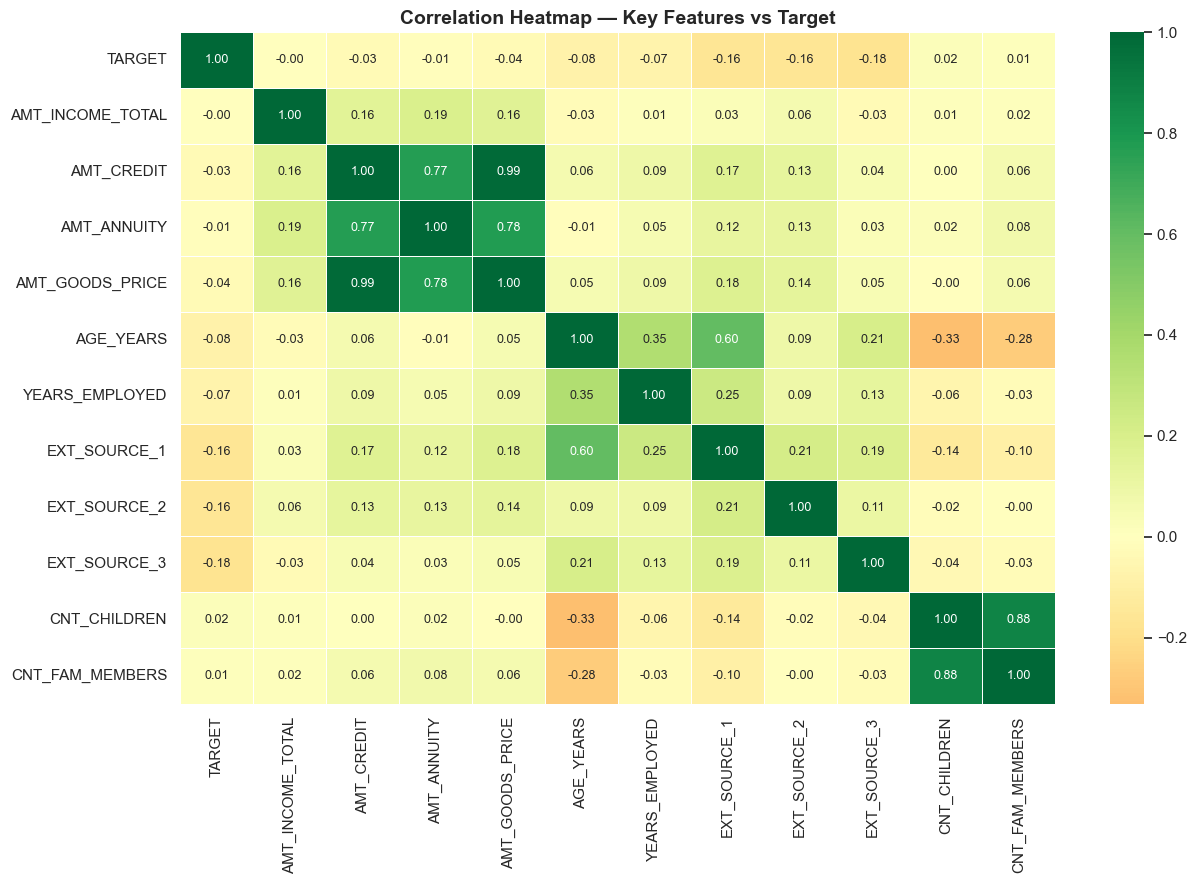

✅ Chart saved to images/correlation_heatmap.png


In [18]:
# Select numerical columns for correlation
corr_cols = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_GOODS_PRICE', 'AGE_YEARS', 'YEARS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Heatmap — Key Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/correlation_heatmap.png")

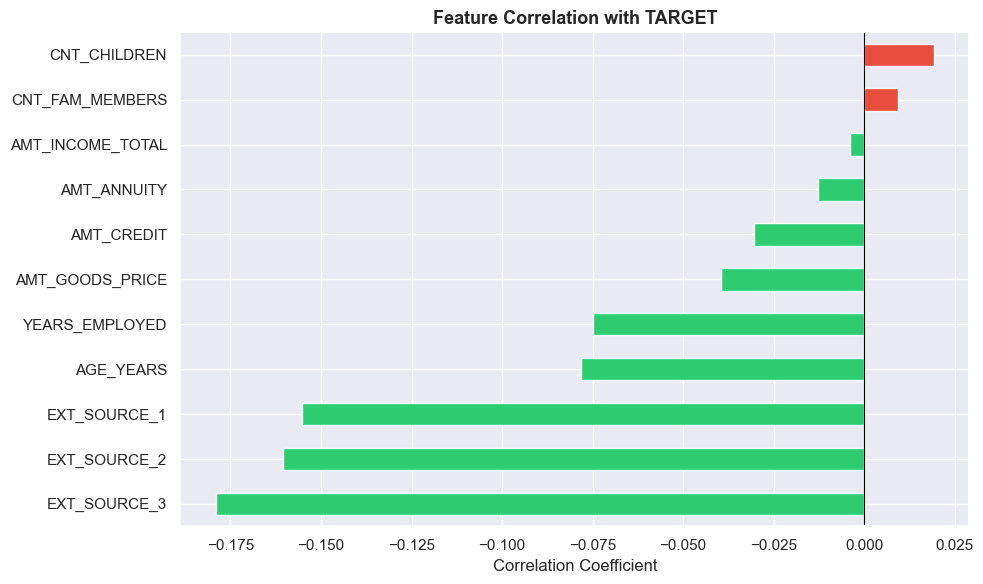

✅ Chart saved to images/target_correlation.png


In [19]:
# Correlation with TARGET specifically
target_corr = corr_matrix['TARGET'].drop('TARGET').sort_values()

plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh', color=['#e74c3c' if x > 0 else '#2ecc71' for x in target_corr])
plt.title('Feature Correlation with TARGET', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../images/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/target_correlation.png")

> **Key Insights:**
> - `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` — strongest negative correlation with default (higher score = less likely to default)
> - `DAYS_BIRTH` (AGE) — older applicants default less
> - `AMT_CREDIT` and `AMT_GOODS_PRICE` — slightly positively correlated with default

### Step 10 — EDA Summary & Findings
Key takeaways from the exploratory data analysis before moving to feature engineering.

In [20]:
print("=" * 55)
print("         EDA SUMMARY — BANK LOAN DEFAULT RISK")
print("=" * 55)
print(f"\n📊 Dataset Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🎯 Default Rate       : {df['TARGET'].mean()*100:.2f}%")
print(f"⚠️  Class Imbalance    : {(df['TARGET']==0).sum()/(df['TARGET']==1).sum():.1f}:1")
print(f"❌ Columns w/ Missing : {df.isnull().any().sum()} out of {df.shape[1]}")
print(f"👤 Age Range          : {df['AGE_YEARS'].min()}–{df['AGE_YEARS'].max()} years")
print(f"💰 Avg Credit Amount  : ₹{df['AMT_CREDIT'].mean():,.0f}")
print(f"💵 Avg Income         : ₹{df['AMT_INCOME_TOTAL'].mean():,.0f}")
print("\n✅ EDA Complete — Moving to Feature Engineering")
print("=" * 55)

         EDA SUMMARY — BANK LOAN DEFAULT RISK

📊 Dataset Shape      : 307,511 rows × 125 columns
🎯 Default Rate       : 8.07%
⚠️  Class Imbalance    : 11.4:1
❌ Columns w/ Missing : 69 out of 125
👤 Age Range          : 20–69 years
💰 Avg Credit Amount  : ₹599,026
💵 Avg Income         : ₹168,798

✅ EDA Complete — Moving to Feature Engineering
